In [2]:
pip install matplotlib --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 40.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 29.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 36.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [3]:
import re
import json
import glob
import matplotlib.pyplot as plt

In [11]:
import os
print(os.getcwd())

/home/jovyan/work


   Request Rate    Queue Time (ms)   Compute Infer (ms)   Stable
-----------------------------------------------------------------
           80.0              0.074                6.707      Yes
          100.0              0.057                5.845      Yes
          120.0              0.102                5.267      Yes
          140.0              0.136                4.613      Yes
          160.0              0.131                4.053      Yes
          180.0              0.193                3.634      Yes
          200.0              0.457                3.254       No
          220.0              0.168                2.918      Yes
          240.0              0.609                2.923       No
          260.0              0.505                2.917       No
          280.0              1.794                2.902       No
          300.0              3.031                2.918       No
          320.0              8.871                2.885       No
          340.0         

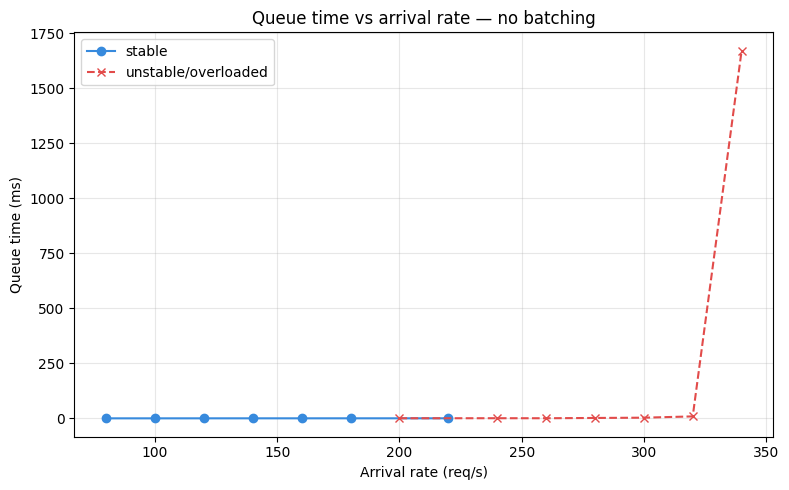

In [17]:
def parse_perf_file(filepath):
    with open(filepath, 'r') as f:
        text = f.read()
    
    # Rate from filename
    m = re.search(r'no_batch_(\d+)\.txt', filepath)
    request_rate = float(m.group(1)) if m else None
    
    m = re.search(r'queue (\d+) usec', text)
    queue_time_ms = int(m.group(1)) / 1000 if m else None
    
    unstable = 'not stabilizing' in text.lower() or 'were delayed' in text
    m = re.search(r'compute infer (\d+) usec', text)
    compute_infer_ms = int(m.group(1)) / 1000 if m else None

    return {'request_rate': request_rate, 'queue_time_ms': queue_time_ms, 'compute_infer_ms': compute_infer_ms, 'unstable': unstable}

results = sorted(
    [parse_perf_file(f) for f in glob.glob('/home/jovyan/work/no_batch_results/no_batch_*.txt')],
    key=lambda r: r['request_rate']
)

print(f"{'Request Rate':>15} {'Queue Time (ms)':>18} {'Compute Infer (ms)':>20} {'Stable':>8}")
print("-" * 65)
for r in results:
    print(f"{r['request_rate']:>15.1f} {r['queue_time_ms']:>18.3f} {r['compute_infer_ms']:>20.3f} {'No' if r['unstable'] else 'Yes':>8}")

stable   = [r for r in results if not r['unstable']]
unstable = [r for r in results if r['unstable']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([r['request_rate'] for r in stable],   [r['queue_time_ms'] for r in stable],   'o-',  color='#378ADD', label='stable')
ax.plot([r['request_rate'] for r in unstable], [r['queue_time_ms'] for r in unstable], 'x--', color='#E24B4A', label='unstable/overloaded')

ax.set_xlabel('Arrival rate (req/s)')
ax.set_ylabel('Queue time (ms)')
ax.set_title('Queue time vs arrival rate — no batching')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('queue_vs_rate_no_batch.png', dpi=150)
plt.show()

In [16]:
for r in results:
    print(r)

{'request_rate': 80.0, 'queue_time_ms': 0.074, 'compute_infer_ms': 6.707, 'unstable': False}
{'request_rate': 100.0, 'queue_time_ms': 0.057, 'compute_infer_ms': 5.845, 'unstable': False}
{'request_rate': 120.0, 'queue_time_ms': 0.102, 'compute_infer_ms': 5.267, 'unstable': False}
{'request_rate': 140.0, 'queue_time_ms': 0.136, 'compute_infer_ms': 4.613, 'unstable': False}
{'request_rate': 160.0, 'queue_time_ms': 0.131, 'compute_infer_ms': 4.053, 'unstable': False}
{'request_rate': 180.0, 'queue_time_ms': 0.193, 'compute_infer_ms': 3.634, 'unstable': False}
{'request_rate': 200.0, 'queue_time_ms': 0.457, 'compute_infer_ms': 3.254, 'unstable': True}
{'request_rate': 220.0, 'queue_time_ms': 0.168, 'compute_infer_ms': 2.918, 'unstable': False}
{'request_rate': 240.0, 'queue_time_ms': 0.609, 'compute_infer_ms': 2.923, 'unstable': True}
{'request_rate': 260.0, 'queue_time_ms': 0.505, 'compute_infer_ms': 2.917, 'unstable': True}
{'request_rate': 280.0, 'queue_time_ms': 1.794, 'compute_infer_m